In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option('display.float_format', lambda x: '{:.2f}'.format(x))

1. **Load the Foreign Gifts Data**

In [17]:
df = pd.read_csv("ForeignGifts_edu.csv")
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


2. **Describe the difference between different classes of gift types.**

In [3]:
df['Gift Type'].unique()

array(['Monetary Gift', 'Contract', 'Real Estate'], dtype=object)

The different types of Gifts are Monetary Gift, which would be direct monetary funds, Contract which may refer to research contracts and defined terms for monetary gifts, and Real Estate which would be direct transfer of real estate/property/physical assets.

3.

<div class="alert alert-block alert-warning">
<b>Question 1:</b>  Which country gives the most money, in total?
</div>

In [4]:
df.groupby("Country of Giftor")["Foreign Gift Amount"].sum().nlargest(5)

Country of Giftor
QATAR           2706240869
ENGLAND         1464906771
CHINA           1237952112
SAUDI ARABIA    1065205930
BERMUDA          899593972
Name: Foreign Gift Amount, dtype: int64

The country that gives the most money in total is Qatar.

<div class="alert alert-block alert-warning">
<b>Question 2:</b>  Which country initiates the most gifts, by count?
</div>


In [5]:
df.groupby("Country of Giftor")["Foreign Gift Amount"].count().nlargest(5)

Country of Giftor
ENGLAND        3655
CHINA          2461
CANADA         2344
JAPAN          1896
SWITZERLAND    1676
Name: Foreign Gift Amount, dtype: int64

The country that initiates the most gifts, by count is England.

<div class="alert alert-block alert-warning">
<b>Question 3:</b>  Which country gives the largest gifts, on average?
</div>

In [6]:
df.groupby("Country of Giftor")["Foreign Gift Amount"].mean().nlargest(5)

Country of Giftor
BERMUDA   7688837.37
ECUADOR   3985140.29
QATAR     3905109.48
ANTIGUA   3435545.00
JERSEY    3064588.83
Name: Foreign Gift Amount, dtype: float64

## Ordering by institution

<div class="alert alert-block alert-warning">
<b>Question 4:</b>  Which institution receive the most money, in total?
</div>

In [7]:
df.groupby("Institution Name")["Foreign Gift Amount"].sum().nlargest(5)

Institution Name
Carnegie Mellon University               1477922504
Cornell University                       1289937761
Harvard University                        954803610
Massachusetts Institute of Technology     859071692
Yale University                           613441311
Name: Foreign Gift Amount, dtype: int64

The institution receiving the most money in total is Carnegie Mellon University.

<div class="alert alert-block alert-warning">
<b>Question 5:</b>  Which institution receive the greatest number of gifts, by count?
</div>

Build a plot of the top 20 institutions by the amount or number of gifts they have received using either seaborn or plotly. 

In [8]:
df.groupby("Institution Name")["Foreign Gift Amount"].count().nlargest(5)

Institution Name
University of California, Los Angeles          3916
California Institute of Technology             2502
Columbia University in the City of New York    1127
Ohio State University (The)                    1014
Johns Hopkins University                        899
Name: Foreign Gift Amount, dtype: int64

The institution receiving the greatest number of gifts by count is University of California, Los Angeles.

Bar plot of the top 20 institutions by the number of gifts recieved:

Text(0, 0.5, 'Gift Amount (Count)')

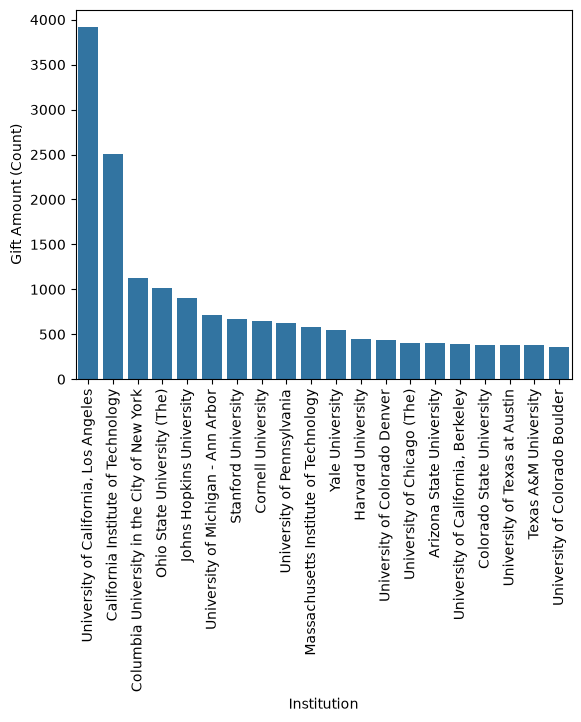

In [9]:
df_inst_count = df.groupby("Institution Name")["Foreign Gift Amount"].count().nlargest(20)
sns.barplot(df_inst_count)
plt.xticks(rotation='vertical')
plt.xlabel("Institution")
plt.ylabel("Gift Amount (Count)")

## Comparing summary statistics

<div class="alert alert-block alert-warning">
<b>Question 6:</b>  What is the average amount each university receives? Median amount? If they are different, why?
</div>

Plot a histogram of the amounts received by each university, and then label the median and the mean as vertical lines.


In [10]:
df.groupby("Institution Name")['Foreign Gift Amount'].sum().sort_values(ascending=False).describe()

count          318.00
mean      52202878.97
std      153571596.53
min            500.00
25%        1588841.50
50%        6486791.50
75%       31770629.75
max     1477922504.00
Name: Foreign Gift Amount, dtype: float64

The average amount recieved by each university $52,202,878.97 while the median amount recieved by each university is $6,486,791.50

They are drastically different with the mean being greater than the median. This is most likely due to the data having a small amount of institutions recieving very large amounts with the rest of the institutions recieving much smaller total amounts in comparison, causing the data to be heavily skewed with a long tail.

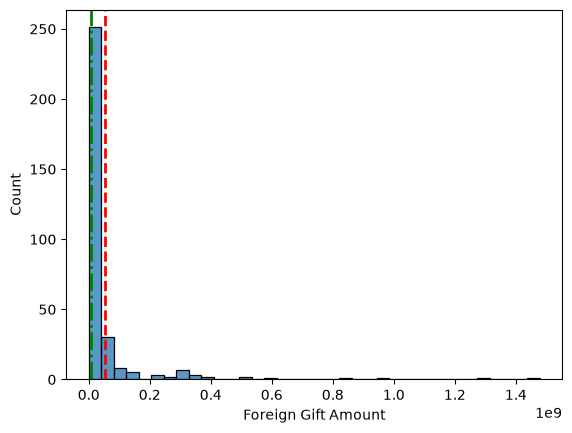

In [11]:
df_amt_inst = df.groupby("Institution Name")['Foreign Gift Amount'].sum().sort_values(ascending=False)
sns.histplot(df_amt_inst)
mean_val = df_amt_inst.mean()
median_val = df_amt_inst.median()
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='dashdot', linewidth=2, label=f'Median: {median_val:.2f}')

If we want a more normalized distribution of this data we can use a log-transformation to better visualize it.

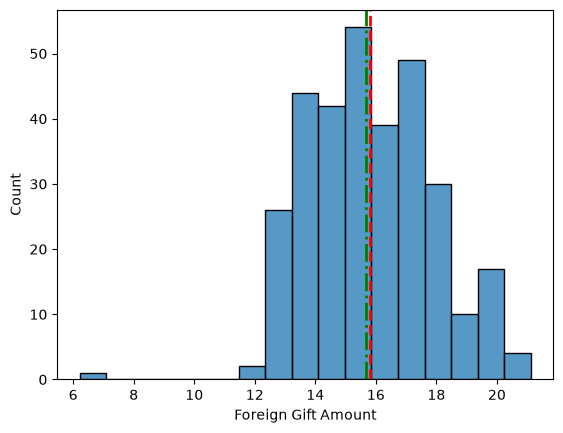

In [12]:
df_amt_log = np.log(df.groupby("Institution Name")['Foreign Gift Amount'].sum().sort_values(ascending=False))
sns.histplot(df_amt_log)
mean_val = df_amt_log.mean()
median_val = df_amt_log.median()
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='dashdot', linewidth=2, label=f'Median: {median_val:.2f}')

## Relationship between variables: 
<div class="alert alert-block alert-warning">
<b>Question 7:</b>  What is the largest flow of a single country to a single institution?
</div>

### Cross-tabulation
First, use `pd.crosstab` to look at the relationship between outcoming gifts from countries and incoming gifts to institutions. 

In [ ]:
pd.crosstab(df['Country of Giftor'], df['Institution Name'])

# if we wanted to see a crosstab based on foreign gift amount rather than count of gifts we would use:
#pd.crosstab(index=df['Country of Giftor'], columns=df['Institution Name'], values=df['Foreign Gift Amount'], aggfunc='sum')

Institution Name,Adelphi University,Albert Einstein College of Medicine,Alfred University,American University (The),Amherst College,Arizona State University,Auburn University Montgomery,Babson College,Ball State University,Barnard College,...,Wilkes University,William Marshall Rice University,Williams College,Winthrop University,Worcester Polytechnic Institute,Wright State University,Xavier University of Louisiana,Yale University,Yeshiva University,Young Americans College of the Performing Arts (The)
Country of Giftor,,,,,,,,,,,,,,,,,,,,,
AFGHANISTAN,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AMERICAN SAMOA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ANGOLA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ANTIGUA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ARGENTINA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VIRGIN ISLANDS (BRITISH),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,2,0,0
WALES,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
YEMEN,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


This cross tabulation, though it does show us interaction of gifts from which country to which institution, is hard to read/interpret to find any one interaction between either group. To answer the same question, we could use an alluvial plot as shown below.

In [14]:
import plotly.graph_objects as go

giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 20

flows = (
    df.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()

The largest flow of a single country to a single institution from the above alluvial plot is Qatar to Cornell University.

<div class="alert alert-block alert-warning">
<b>Question 8:</b>  Which are the top giftors to US academic institutions?
</div>

In [15]:
df.groupby('Giftor Name')['Foreign Gift Amount'].sum().nlargest(20)

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Sanofi-Aventis Recerche                  62106706
Saudi Arabia                             59450098
Sanofi-Aventis Recherche                 58520202
Skolkovo Foundation                      51500000
Stavros S. Niarchos Foundation        

The above are the top 20 giftors to US Academic Institutions with the Qatar Foundation being the top giftor.